In [1]:
# import warnings
# from numba.core.errors import NumbaWarning, NumbaPerformanceWarning

# warnings.filterwarnings("ignore", category=NumbaWarning)
# warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

from ler import LeR

ler = LeR()


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/a

In [2]:
lensed_param = ler.sample_lens_parameters(10)

zs = lensed_param["zs"]
zl = lensed_param["zl"]
sigma = lensed_param["sigma"]
q = lensed_param["q"]
phi = lensed_param["phi"]
gamma = lensed_param["gamma"]
gamma1 = lensed_param["gamma1"]
gamma2 = lensed_param["gamma2"]

sampling lens parameters with sample_all_routine_epl_shear_sl...


In [10]:
# interpolation
ler.cross_section(zs, zl, sigma, q, phi, gamma, gamma1, gamma2)

array([8.69249152e-12, 5.20242636e-11, 1.99372864e-10,
       9.70888280e-12, 3.45318130e-12, 1.10610363e-12,
       2.28484170e-11, 2.67255525e-11, 3.49886699e-10,
       1.94291531e-10])

In [4]:
# lenstronomy
theta_E = ler.compute_einstein_radii(sigma, zl, zs)
ler.cross_section_epl_shear_numerical_mp(
    theta_E,
    gamma,
    gamma1,
    gamma2,
    q,
    phi,
)

array([8.67700138e-12, 5.13752947e-11, 1.99055795e-10,
       9.04522809e-12, 3.42036879e-12, 1.06205483e-12,
       2.21230541e-11, 2.63323912e-11, 3.49996065e-10,
       1.92286796e-10])

In [7]:
Da_instance = ler.angular_diameter_distance.function
from ler.image_properties.cross_section_njit import make_cross_section_reinit
cross_section_epl_shear_njit = make_cross_section_reinit(Da_instance)

In [8]:
# lenstronomy with njitted cross-section
cross_section_epl_shear_njit(
   zs, zl, sigma, q, phi, gamma, gamma1, gamma2 
)

array([8.67700107e-12, 5.13752947e-11, 1.99055795e-10,
       9.04522809e-12, 3.42036855e-12, 1.06205483e-12,
       2.21230469e-11, 2.63323912e-11, 3.49996065e-10,
       1.92286767e-10])

sampling lens parameters with sample_all_routine_epl_shear_sl...
=== Runtime (s) over 5 repeats ===
Interpolation  : 0.0113 ± 0.0004
Lenstronomy    : 0.7458 ± 0.0120
Lenstronomy+JIT: 0.3654 ± 0.0046

=== Agreement vs Lenstronomy (reference) ===
Interpolation rel err: mean=2.466e-02, median=1.266e-02, p90=5.911e-02, p99=1.719e-01, max=7.011e-01
NJIT rel err: mean=1.155e-07, median=1.439e-15, p90=3.222e-07, p99=1.468e-06, max=4.454e-06


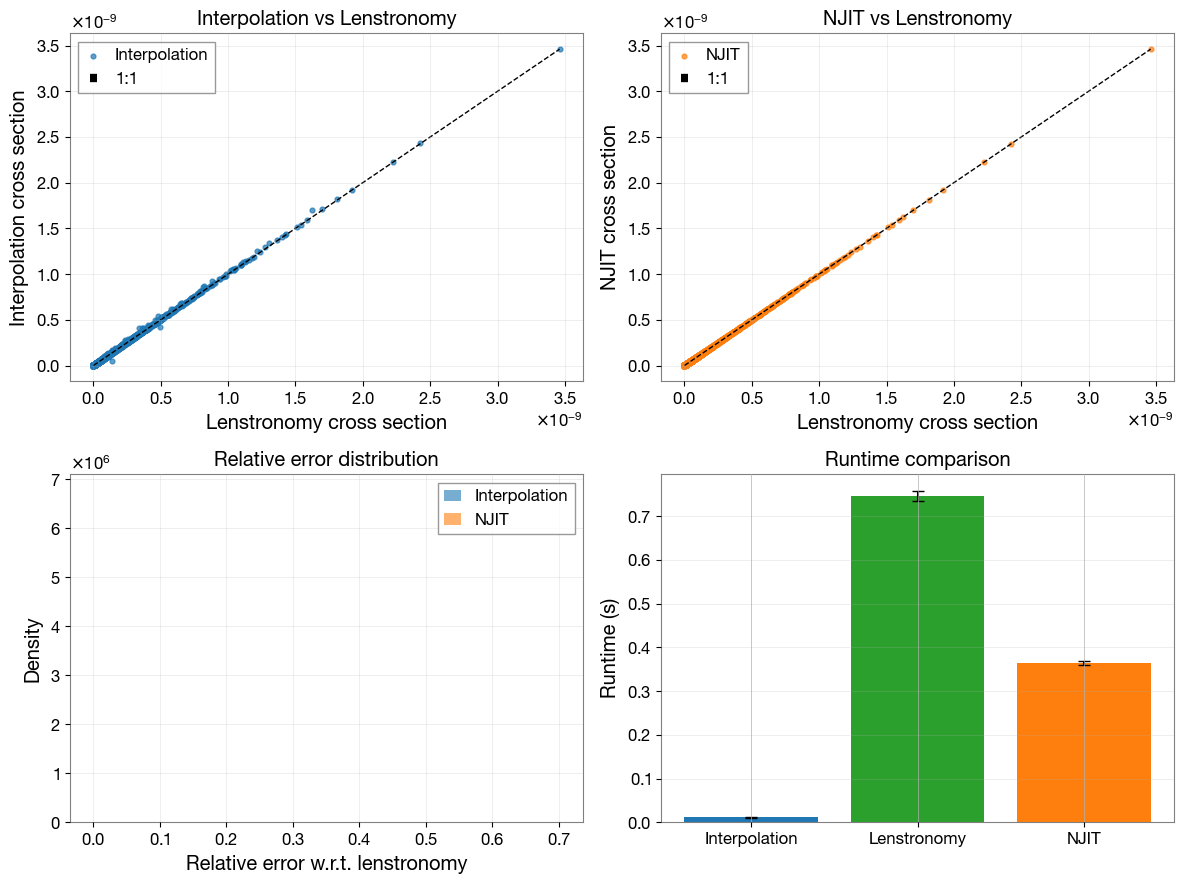

In [13]:
# Robust comparison: interpolation vs lenstronomy vs njitted lenstronomy
import time
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Build a robust sample
# -------------------------
rng = np.random.default_rng(1234)
n_samples = 10000

lensed_param_cmp = ler.sample_lens_parameters(n_samples)
zs_cmp = lensed_param_cmp["zs"]
zl_cmp = lensed_param_cmp["zl"]
sigma_cmp = lensed_param_cmp["sigma"]
q_cmp = lensed_param_cmp["q"]
phi_cmp = lensed_param_cmp["phi"]
gamma_cmp = lensed_param_cmp["gamma"]
gamma1_cmp = lensed_param_cmp["gamma1"]
gamma2_cmp = lensed_param_cmp["gamma2"]

# Deterministic shuffle (robust against ordering artifacts)
idx = rng.permutation(n_samples)
zs_cmp = zs_cmp[idx]
zl_cmp = zl_cmp[idx]
sigma_cmp = sigma_cmp[idx]
q_cmp = q_cmp[idx]
phi_cmp = phi_cmp[idx]
gamma_cmp = gamma_cmp[idx]
gamma1_cmp = gamma1_cmp[idx]
gamma2_cmp = gamma2_cmp[idx]

# -------------------------
# 2) Define calculators
# -------------------------
thetaE_cmp = ler.compute_einstein_radii(sigma_cmp, zl_cmp, zs_cmp)

def calc_interpolation():
    return np.asarray(
        ler.cross_section(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

def calc_lenstronomy():
    return np.asarray(
        ler.cross_section_epl_shear_numerical_mp(
            thetaE_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp, q_cmp, phi_cmp
        )
    )

def calc_njit():
    return np.asarray(
        cross_section_epl_shear_njit(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

# Warm-up JIT and any internal caches
_ = calc_njit()
_ = calc_interpolation()
_ = calc_lenstronomy()

def timed(fn, repeat=3):
    times = []
    out = None
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - t0)
    return out, np.mean(times), np.std(times)

# -------------------------
# 3) Run + benchmark
# -------------------------
cs_interp, t_interp_mean, t_interp_std = timed(calc_interpolation, repeat=5)
cs_lens, t_lens_mean, t_lens_std = timed(calc_lenstronomy, repeat=5)
cs_njit, t_njit_mean, t_njit_std = timed(calc_njit, repeat=5)

# -------------------------
# 4) Robust error metrics
# -------------------------
eps = 1e-20
safe_lens = np.maximum(np.abs(cs_lens), eps)

abs_err_interp = np.abs(cs_interp - cs_lens)
abs_err_njit = np.abs(cs_njit - cs_lens)

rel_err_interp = abs_err_interp / safe_lens
rel_err_njit = abs_err_njit / safe_lens

def summarize(name, arr):
    q50, q90, q99 = np.quantile(arr, [0.50, 0.90, 0.99])
    return f"{name}: mean={arr.mean():.3e}, median={q50:.3e}, p90={q90:.3e}, p99={q99:.3e}, max={arr.max():.3e}"

print("=== Runtime (s) over 5 repeats ===")
print(f"Interpolation  : {t_interp_mean:.4f} ± {t_interp_std:.4f}")
print(f"Lenstronomy    : {t_lens_mean:.4f} ± {t_lens_std:.4f}")
print(f"Lenstronomy+JIT: {t_njit_mean:.4f} ± {t_njit_std:.4f}")
print()
print("=== Agreement vs Lenstronomy (reference) ===")
print(summarize("Interpolation rel err", rel_err_interp))
print(summarize("NJIT rel err", rel_err_njit))

# -------------------------
# 5) Plot comparison
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Scatter: interpolation vs lenstronomy
ax = axes[0, 0]
ax.scatter(cs_lens, cs_interp, s=12, alpha=0.7, label="Interpolation")
lims = [
    np.nanmin([cs_lens.min(), cs_interp.min()]),
    np.nanmax([cs_lens.max(), cs_interp.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("Interpolation cross section")
ax.set_title("Interpolation vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# (b) Scatter: njit vs lenstronomy
ax = axes[0, 1]
ax.scatter(cs_lens, cs_njit, s=12, alpha=0.7, color="tab:orange", label="NJIT")
lims = [
    np.nanmin([cs_lens.min(), cs_njit.min()]),
    np.nanmax([cs_lens.max(), cs_njit.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("NJIT cross section")
ax.set_title("NJIT vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# (c) Relative error distributions
ax = axes[1, 0]
ax.hist(rel_err_interp, bins=40, alpha=0.6, label="Interpolation", density=True)
ax.hist(rel_err_njit, bins=40, alpha=0.6, label="NJIT", density=True)
ax.set_xlabel("Relative error w.r.t. lenstronomy")
ax.set_ylabel("Density")
ax.set_title("Relative error distribution")
ax.legend()
ax.grid(alpha=0.3)

# (d) Runtime comparison
ax = axes[1, 1]
labels = ["Interpolation", "Lenstronomy", "NJIT"]
means = [t_interp_mean, t_lens_mean, t_njit_mean]
stds = [t_interp_std, t_lens_std, t_njit_std]
ax.bar(labels, means, yerr=stds, capsize=4, color=["tab:blue", "tab:green", "tab:orange"])
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime comparison")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

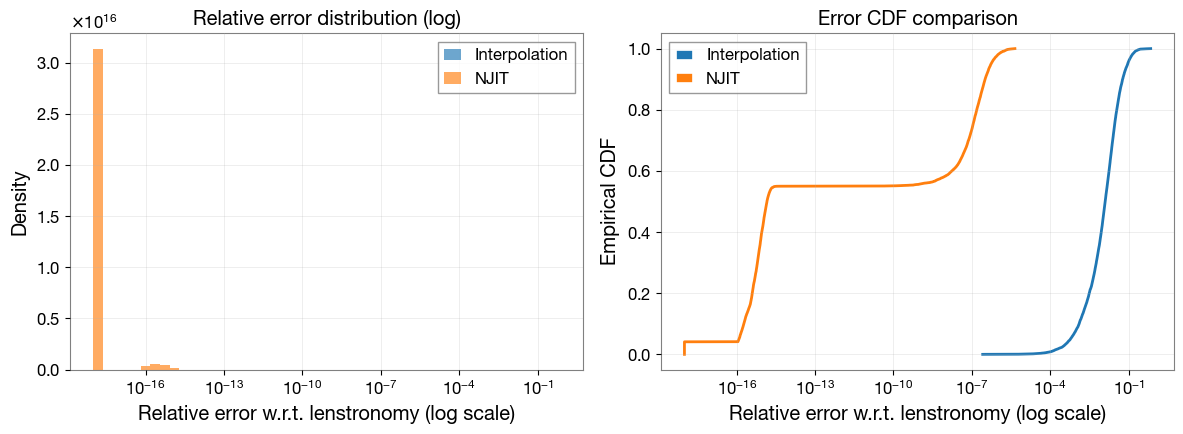

Quantiles of relative error (w.r.t. lenstronomy):
Interpolation  median=1.266e-02, p90=5.911e-02, p99=1.719e-01, max=7.011e-01
NJIT           median=1.439e-15, p90=3.222e-07, p99=1.468e-06, max=4.454e-06


In [14]:
# Extra diagnostics: log-scale error view + CDF comparison
import numpy as np
import matplotlib.pyplot as plt

# Safety floor for log scale
eps_plot = 1e-18
err_interp_plot = np.maximum(rel_err_interp, eps_plot)
err_njit_plot = np.maximum(rel_err_njit, eps_plot)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (1) Log-scale histogram
ax = axes[0]
bins = np.logspace(
    np.log10(min(err_interp_plot.min(), err_njit_plot.min())),
    np.log10(max(err_interp_plot.max(), err_njit_plot.max())),
    50,
    )
ax.hist(err_interp_plot, bins=bins, alpha=0.65, density=True, label="Interpolation")
ax.hist(err_njit_plot, bins=bins, alpha=0.65, density=True, label="NJIT")
ax.set_xscale("log")
ax.set_xlabel("Relative error w.r.t. lenstronomy (log scale)")
ax.set_ylabel("Density")
ax.set_title("Relative error distribution (log)")
ax.grid(alpha=0.3, which="both")
ax.legend()

# (2) Empirical CDF
ax = axes[1]
for values, label in [(err_interp_plot, "Interpolation"), (err_njit_plot, "NJIT")]:
    sorted_vals = np.sort(values)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, cdf, lw=2, label=label)

ax.set_xscale("log")
ax.set_xlabel("Relative error w.r.t. lenstronomy (log scale)")
ax.set_ylabel("Empirical CDF")
ax.set_title("Error CDF comparison")
ax.grid(alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.show()

print("Quantiles of relative error (w.r.t. lenstronomy):")
for arr, name in [(rel_err_interp, "Interpolation"), (rel_err_njit, "NJIT")]:
    q50, q90, q99 = np.quantile(arr, [0.5, 0.9, 0.99])
    print(f"{name:14s} median={q50:.3e}, p90={q90:.3e}, p99={q99:.3e}, max={arr.max():.3e}")

Total samples: 10000
Top 5.0% threshold (relative error): 9.230e-02
Global median / p90 / p99 / max: 1.266e-02 / 5.911e-02 / 1.719e-01 / 7.011e-01

Parameter ranges in high-error subset:
q            all[p05,p50,p95]=(0.355, 0.688, 0.917)  high_err[p05,p50,p95]=(0.229, 0.359, 0.483)
gamma        all[p05,p50,p95]=(1.89, 2.1, 2.31)  high_err[p05,p50,p95]=(1.82, 2.06, 2.26)
|shear|      all[p05,p50,p95]=(0.0159, 0.0582, 0.123)  high_err[p05,p50,p95]=(0.0149, 0.0589, 0.121)
gamma1       all[p05,p50,p95]=(-0.0822, 0.000297, 0.0846)  high_err[p05,p50,p95]=(-0.087, -0.00357, 0.0861)
gamma2       all[p05,p50,p95]=(-0.082, -0.00108, 0.082)  high_err[p05,p50,p95]=(-0.078, -0.000572, 0.0867)
ellipticity  all[p05,p50,p95]=(0.0433, 0.184, 0.476)  high_err[p05,p50,p95]=(0.348, 0.472, 0.627)
theta_E      all[p05,p50,p95]=(6.23e-07, 2.27e-06, 7.06e-06)  high_err[p05,p50,p95]=(5.83e-07, 1.79e-06, 5.38e-06)
zl           all[p05,p50,p95]=(0.279, 0.891, 2.14)  high_err[p05,p50,p95]=(0.265, 0.906, 2.07)
zs

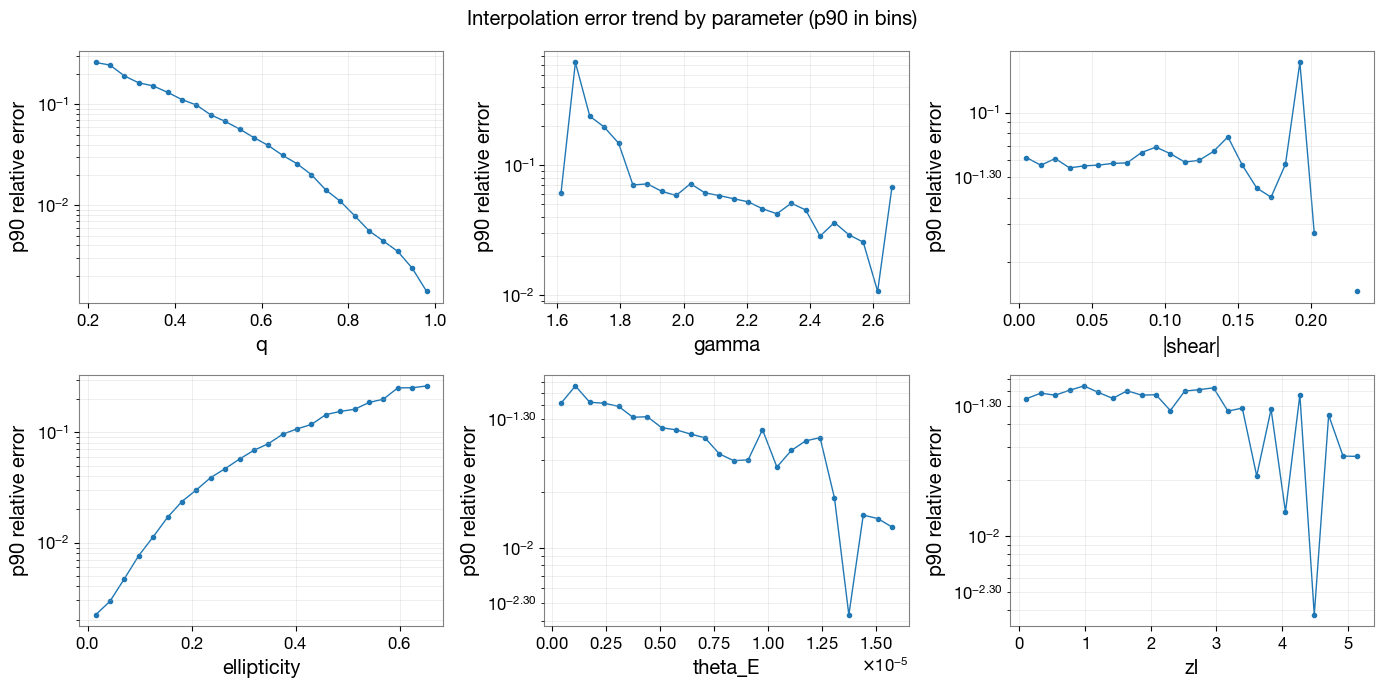

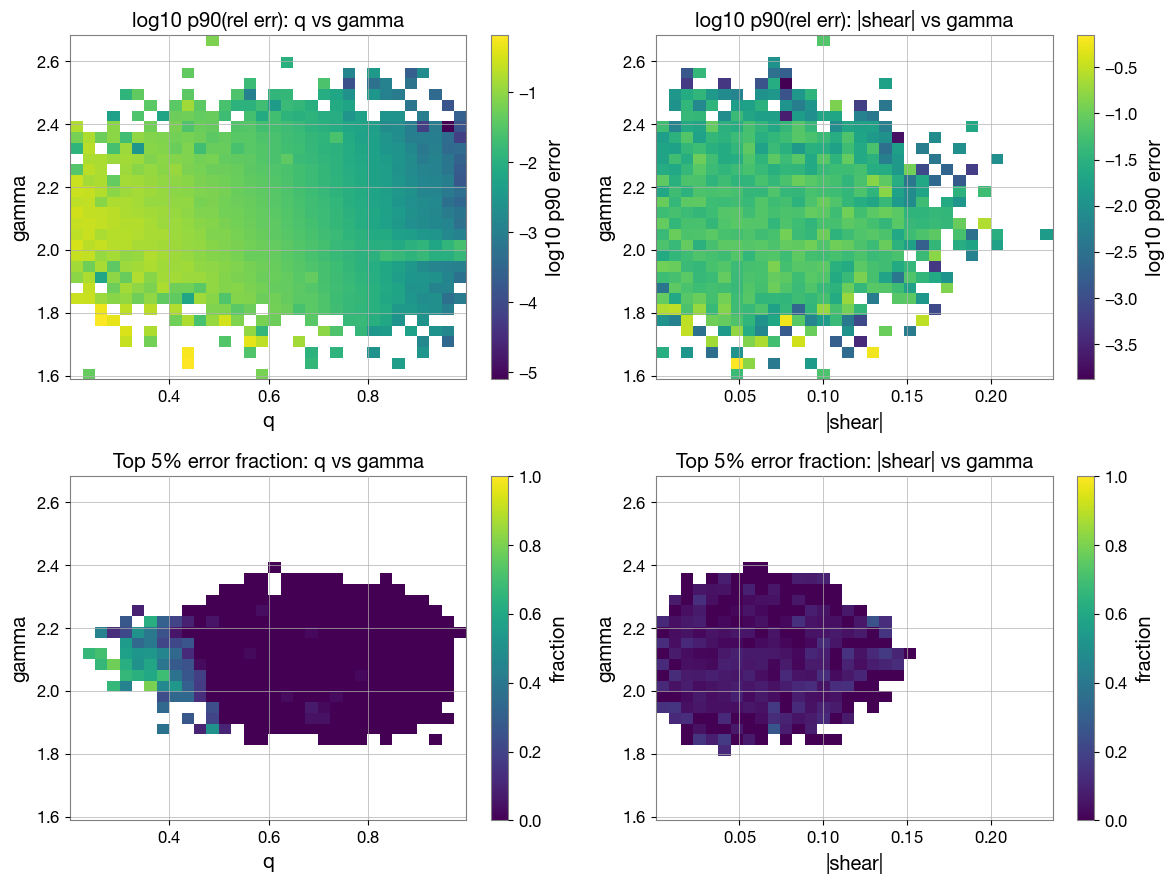

In [16]:
# Where does interpolation error increase? (parameter-space diagnosis)
import numpy as np
import matplotlib.pyplot as plt

rel = rel_err_interp
log_rel = np.log10(np.maximum(rel, 1e-18))

# Derived parameters
ellipticity = (1.0 - q_cmp) / (1.0 + q_cmp)
shear_mag = np.sqrt(gamma1_cmp**2 + gamma2_cmp**2)

# Top-error region
q_hi = 0.95
thr = np.quantile(rel, q_hi)
hi = rel >= thr

print(f"Total samples: {rel.size}")
print(f"Top {(1-q_hi)*100:.1f}% threshold (relative error): {thr:.3e}")
print(f"Global median / p90 / p99 / max: {np.quantile(rel,0.5):.3e} / {np.quantile(rel,0.9):.3e} / {np.quantile(rel,0.99):.3e} / {rel.max():.3e}")

def summarize_param(name, x):
    q_all = np.quantile(x, [0.05, 0.5, 0.95])
    q_bad = np.quantile(x[hi], [0.05, 0.5, 0.95])
    print(
        f"{name:12s} all[p05,p50,p95]=({q_all[0]:.3g}, {q_all[1]:.3g}, {q_all[2]:.3g})  "
        f"high_err[p05,p50,p95]=({q_bad[0]:.3g}, {q_bad[1]:.3g}, {q_bad[2]:.3g})"
    )

print("\nParameter ranges in high-error subset:")
summarize_param("q", q_cmp)
summarize_param("gamma", gamma_cmp)
summarize_param("|shear|", shear_mag)
summarize_param("gamma1", gamma1_cmp)
summarize_param("gamma2", gamma2_cmp)
summarize_param("ellipticity", ellipticity)
summarize_param("theta_E", thetaE_cmp)
summarize_param("zl", zl_cmp)
summarize_param("zs", zs_cmp)

# ----- 1D binned p90(error) vs each parameter -----
def binned_p90(x, y, nbins=24):
    edges = np.linspace(np.min(x), np.max(x), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    out = np.full(nbins, np.nan)
    for i in range(nbins):
        m = (x >= edges[i]) & (x < edges[i + 1]) if i < nbins - 1 else (x >= edges[i]) & (x <= edges[i + 1])
        if np.any(m):
            out[i] = np.quantile(y[m], 0.90)
    return centers, out

params = [
    (q_cmp, "q"),
    (gamma_cmp, "gamma"),
    (shear_mag, "|shear|"),
    (ellipticity, "ellipticity"),
    (thetaE_cmp, "theta_E"),
    (zl_cmp, "zl"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (x, name) in zip(axes.ravel(), params):
    c, v = binned_p90(x, rel, nbins=24)
    ax.plot(c, v, marker="o", ms=3, lw=1)
    ax.set_yscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel("p90 relative error")
    ax.grid(alpha=0.3, which="both")

plt.suptitle("Interpolation error trend by parameter (p90 in bins)")
plt.tight_layout()
plt.show()

# ----- 2D maps of high-error density and p90 error -----
def binned_stat_2d(x, y, z, nx=35, ny=35, qstat=0.90):
    xedges = np.linspace(np.min(x), np.max(x), nx + 1)
    yedges = np.linspace(np.min(y), np.max(y), ny + 1)
    out = np.full((ny, nx), np.nan)
    for i in range(nx):
        mx = (x >= xedges[i]) & (x < xedges[i + 1]) if i < nx - 1 else (x >= xedges[i]) & (x <= xedges[i + 1])
        for j in range(ny):
            my = (y >= yedges[j]) & (y < yedges[j + 1]) if j < ny - 1 else (y >= yedges[j]) & (y <= yedges[j + 1])
            m = mx & my
            if np.any(m):
                out[j, i] = np.quantile(z[m], qstat)
    return out, xedges, yedges

def high_error_fraction_2d(x, y, mask_hi, nx=35, ny=35):
    xedges = np.linspace(np.min(x), np.max(x), nx + 1)
    yedges = np.linspace(np.min(y), np.max(y), ny + 1)
    out = np.full((ny, nx), np.nan)
    for i in range(nx):
        mx = (x >= xedges[i]) & (x < xedges[i + 1]) if i < nx - 1 else (x >= xedges[i]) & (x <= xedges[i + 1])
        for j in range(ny):
            my = (y >= yedges[j]) & (y < yedges[j + 1]) if j < ny - 1 else (y >= yedges[j]) & (y <= yedges[j + 1])
            m = mx & my
            n = np.count_nonzero(m)
            if n >= 8:
                out[j, i] = np.count_nonzero(mask_hi[m]) / n
    return out, xedges, yedges

pairs = [
    (q_cmp, gamma_cmp, "q", "gamma"),
    (shear_mag, gamma_cmp, "|shear|", "gamma"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, (x, y, xn, yn) in enumerate(pairs):
    p90map, xe, ye = binned_stat_2d(x, y, rel, nx=32, ny=32, qstat=0.90)
    fracmap, xe2, ye2 = high_error_fraction_2d(x, y, hi, nx=32, ny=32)

    im = axes[0, col].pcolormesh(xe, ye, np.log10(np.maximum(p90map, 1e-18)), shading="auto")
    axes[0, col].set_xlabel(xn)
    axes[0, col].set_ylabel(yn)
    axes[0, col].set_title(f"log10 p90(rel err): {xn} vs {yn}")
    fig.colorbar(im, ax=axes[0, col], label="log10 p90 error")

    im2 = axes[1, col].pcolormesh(xe2, ye2, fracmap, shading="auto", vmin=0, vmax=1)
    axes[1, col].set_xlabel(xn)
    axes[1, col].set_ylabel(yn)
    axes[1, col].set_title(f"Top 5% error fraction: {xn} vs {yn}")
    fig.colorbar(im2, ax=axes[1, col], label="fraction")

plt.tight_layout()
plt.show()

Hybrid fallback region fraction: 0.096

Relative error vs lenstronomy
Interpolation median/p90/p99/max: 1.266e-02 / 5.911e-02 / 1.719e-01 / 7.011e-01
Hybrid        median/p90/p99/max: 9.558e-03 / 4.191e-02 / 9.546e-02 / 7.011e-01

Runtime (single pass, seconds)
Interpolation: 0.0126
Hybrid       : 0.0548
NJIT only    : 0.3928


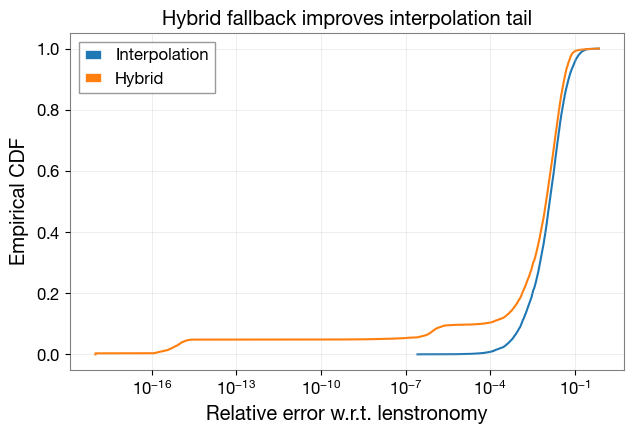

In [17]:
# Practical fix: hybrid evaluator (interpolation + targeted NJIT fallback)
import time
import numpy as np

def cross_section_hybrid(
    zs, zl, sigma, q, phi, gamma, gamma1, gamma2,
    q_cut=0.45, gamma_lo=1.9, gamma_hi=2.25,
    use_shear_cut=False, shear_cut=0.16,
):
    cs_i = np.asarray(ler.cross_section(zs, zl, sigma, q, phi, gamma, gamma1, gamma2))

    # Region where interpolation error is empirically high
    hard = (q <= q_cut) & (gamma >= gamma_lo) & (gamma <= gamma_hi)
    if use_shear_cut:
        hard = hard | (np.sqrt(gamma1**2 + gamma2**2) >= shear_cut)

    if np.any(hard):
        cs_j = np.asarray(
            cross_section_epl_shear_njit(
                zs[hard], zl[hard], sigma[hard], q[hard], phi[hard], gamma[hard], gamma1[hard], gamma2[hard]
            )
        )
        cs_i[hard] = cs_j
    return cs_i, hard

# Evaluate hybrid on the same comparison set
def bench_once(fn):
    t0 = time.perf_counter()
    out = fn()
    return out, time.perf_counter() - t0

cs_hybrid, hard_mask = cross_section_hybrid(
    zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp,
    q_cut=0.45, gamma_lo=1.9, gamma_hi=2.25, use_shear_cut=False,
)

# Runtime comparison (single pass, warm kernel already active)
_, t_interp = bench_once(lambda: ler.cross_section(zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp))
_, t_hybrid = bench_once(lambda: cross_section_hybrid(
    zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
)[0])
_, t_njit = bench_once(lambda: cross_section_epl_shear_njit(
    zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
))

eps = 1e-20
rel_interp_now = np.abs(cs_interp - cs_lens) / np.maximum(np.abs(cs_lens), eps)
rel_hybrid = np.abs(cs_hybrid - cs_lens) / np.maximum(np.abs(cs_lens), eps)

print("Hybrid fallback region fraction:", np.mean(hard_mask))
print("\nRelative error vs lenstronomy")
print(f"Interpolation median/p90/p99/max: {np.quantile(rel_interp_now,0.5):.3e} / {np.quantile(rel_interp_now,0.9):.3e} / {np.quantile(rel_interp_now,0.99):.3e} / {rel_interp_now.max():.3e}")
print(f"Hybrid        median/p90/p99/max: {np.quantile(rel_hybrid,0.5):.3e} / {np.quantile(rel_hybrid,0.9):.3e} / {np.quantile(rel_hybrid,0.99):.3e} / {rel_hybrid.max():.3e}")

print("\nRuntime (single pass, seconds)")
print(f"Interpolation: {t_interp:.4f}")
print(f"Hybrid       : {t_hybrid:.4f}")
print(f"NJIT only    : {t_njit:.4f}")

# Optional quick visual: error CDF improvement
def ecdf(a):
    s = np.sort(a)
    y = np.arange(1, s.size + 1) / s.size
    return s, y

x1, y1 = ecdf(np.maximum(rel_interp_now, 1e-18))
x2, y2 = ecdf(np.maximum(rel_hybrid, 1e-18))

import matplotlib.pyplot as plt
plt.figure(figsize=(6.5, 4.5))
plt.plot(x1, y1, label="Interpolation")
plt.plot(x2, y2, label="Hybrid")
plt.xscale("log")
plt.xlabel("Relative error w.r.t. lenstronomy")
plt.ylabel("Empirical CDF")
plt.title("Hybrid fallback improves interpolation tail")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

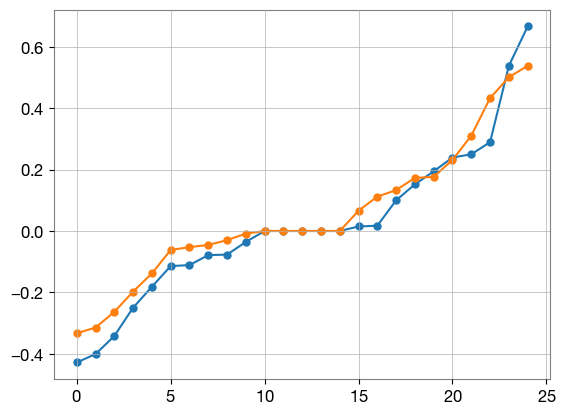

In [27]:
q = np.linspace(0.2, 1.0, 25)
phi = np.linspace(0., 2* np.pi, 25)
def phi_q2_ellipticity(phi, q):
    e = (1.0 - q) / (1.0 + q)
    return e * np.cos(2.0 * phi), e * np.sin(2.0 * phi)
e1, e2 = phi_q2_ellipticity(phi, q)
e1 = np.sort(e1)
e2 = np.sort(e2)

# plot
plt.plot(e1, marker="o", ms=5)
plt.plot(e2, marker="o", ms=5)
plt.show()